# 🎲 Explore Phase III Monte Carlo Simulation Dataset

Loads `outputs/datasets/phase3_monte_carlo_dataset.parquet` — the handoff dataset generated by `scripts/simulations.py` — and visualises the simulated futures (θ) alongside the real measured-now conditions (x̂) that seeded them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA as skPCA
from scipy.stats import chi

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

PARQUET_PATH = "../outputs/simulation/phase3_monte_carlo_dataset.parquet"

X_COLS = [
    'COMP_AXL_DSCHRG_PRESS', 'COMP_Discharge_Pressure', 'COMP_Suction_Pressure',
    'Turbine_SHAFT_SPEED', 'COMP_Discharge_FlowDP',
    'COMP_Discharge_Temp', 'COMP_Suction_Drum_Temperature',
    'TBN_TEMP_1_STG_FWD_INR', 'Exhaust_Temp_Spread_1',
    'SHAFT_BAL_PISTON', 'LUBE_OIL_LVL_XMTR_HI/LO_TNK',
    'DRIVE_MOTOR_Oil_Press', 'SEAL_GAS_SUP_DE', 'SEAL_Primary_DE_Pressure',
]
THETA_COLS = [f'PCA_Coefficient_{i+1}' for i in range(8)]
PC_NAMES   = [f'PC{i+1:02d}' for i in range(8)]

PALETTE = ["#3b82f6","#ef4444","#10b981","#f59e0b",
           "#8b5cf6","#ec4899","#14b8a6","#f43f5e"]

df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print(f"  x̂  columns : {len(X_COLS)}")
print(f"  θ  columns : {len(THETA_COLS)}")
df.head()


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 649, i

Loaded 5,000 rows × 22 columns
  x̂  columns : 14
  θ  columns : 8


,COMP_AXL_DSCHRG_PRESS,COMP_Discharge_Pressure,COMP_Suction_Pressure,Turbine_SHAFT_SPEED,COMP_Discharge_FlowDP,COMP_Discharge_Temp,COMP_Suction_Drum_Temperature,TBN_TEMP_1_STG_FWD_INR,Exhaust_Temp_Spread_1,SHAFT_BAL_PISTON,...,SEAL_GAS_SUP_DE,SEAL_Primary_DE_Pressure,PCA_Coefficient_1,PCA_Coefficient_2,PCA_Coefficient_3,PCA_Coefficient_4,PCA_Coefficient_5,PCA_Coefficient_6,PCA_Coefficient_7,PCA_Coefficient_8
0,0.447916,-0.104954,0.383478,0.248064,0.327159,-0.360754,-0.975908,0.021662,0.002578,0.737229,...,0.183967,0.724753,0.453553,0.147281,-0.175972,0.001283,0.069135,0.361580,0.188945,0.348242
1,0.369208,0.442253,0.567059,0.246352,0.137810,0.123666,-0.472082,0.166747,0.062679,0.772956,...,0.182930,0.627032,0.378007,-1.936135,0.061121,0.075651,-0.129055,-0.024675,-0.051276,-0.002675
2,0.410730,0.226575,0.499444,0.245591,0.405495,0.006863,-0.499833,0.182144,0.145905,0.244329,...,0.182363,0.719582,0.423664,0.324438,0.313187,1.726751,-0.097616,0.062644,-0.662848,0.095279
3,0.246996,-0.284847,-0.210911,0.251375,0.505947,-0.323512,-0.763566,0.007335,-0.420515,1.022131,...,0.182417,0.138687,0.476460,0.421743,-0.052060,0.490480,-0.011919,0.316301,0.014670,0.015445
4,0.484036,0.217195,0.975074,0.249793,0.489790,-0.237526,-0.768918,0.105649,0.391949,-0.235069,...,0.183967,0.667291,0.442343,-0.078614,-0.025172,0.171724,-0.126708,0.008129,0.140203,0.204058


## 1 — Dataset Overview: Basic Stats

In [2]:
print("── θ (generated future-shape PCA coefficients) ──")
display(df[THETA_COLS].describe().round(4))

print("\n── x̂ (measured-now conditions) ──")
display(df[X_COLS].describe().round(4))

── θ (generated future-shape PCA coefficients) ──


,PCA_Coefficient_1,PCA_Coefficient_2,PCA_Coefficient_3,PCA_Coefficient_4,PCA_Coefficient_5,PCA_Coefficient_6,PCA_Coefficient_7,PCA_Coefficient_8
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,0.2761,0.1923,0.0570,0.1485,-0.0397,0.0453,0.0358,0.0430
std,0.4728,0.4651,0.4944,0.6901,0.5038,0.5908,0.6985,0.7952
min,-4.7758,-4.4685,-3.6062,-5.7017,-4.7761,-5.9663,-4.9572,-5.2436
25%,0.3347,0.1261,-0.1049,-0.1048,-0.1758,-0.0742,-0.0829,-0.2449
50%,0.4058,0.1989,-0.0140,0.0431,-0.0984,0.0058,0.0884,-0.0371
75%,0.4528,0.3053,0.0994,0.2344,0.0132,0.1052,0.2294,0.2292
max,2.9978,2.0981,5.7043,5.5458,5.7500,4.7851,4.7409,5.3022



── x̂ (measured-now conditions) ──


,COMP_AXL_DSCHRG_PRESS,COMP_Discharge_Pressure,COMP_Suction_Pressure,Turbine_SHAFT_SPEED,COMP_Discharge_FlowDP,COMP_Discharge_Temp,COMP_Suction_Drum_Temperature,TBN_TEMP_1_STG_FWD_INR,Exhaust_Temp_Spread_1,SHAFT_BAL_PISTON,LUBE_OIL_LVL_XMTR_HI/LO_TNK,DRIVE_MOTOR_Oil_Press,SEAL_GAS_SUP_DE,SEAL_Primary_DE_Pressure
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,0.3833,0.2239,0.6978,0.2353,0.3850,-0.1145,-0.6877,0.0968,0.0585,0.3830,0.6413,0.2062,0.1836,0.5975
std,0.2152,0.2462,0.3856,0.2363,0.2857,0.1816,0.4119,0.1148,0.3105,0.3762,0.0621,0.0261,0.0007,0.3306
min,-1.7665,-1.7066,-2.3218,-4.1411,-2.5917,-0.6327,-2.8224,-0.5346,-2.8452,-0.8119,0.4693,0.1091,0.1818,-2.1851
25%,0.3657,0.1158,0.5189,0.2471,0.3421,-0.2299,-0.8577,0.0587,-0.0406,0.1668,0.5995,0.1913,0.1835,0.4418
50%,0.4171,0.2436,0.7759,0.2489,0.4295,-0.1235,-0.7416,0.1243,0.1087,0.4127,0.6321,0.2103,0.1840,0.6334
75%,0.4785,0.3480,0.9328,0.2502,0.5016,0.0108,-0.5572,0.1659,0.2317,0.6319,0.6793,0.2251,0.1840,0.7724
max,0.5663,0.9261,1.5232,0.2548,0.7357,1.3214,4.8746,0.3109,0.4700,2.4771,0.8832,0.2623,0.1840,1.5271


## 2 — θ Marginal Distributions (Generated Futures)

Each subplot shows the distribution of one PCA coefficient across all 5,000 simulated scenarios.  
A roughly bell-shaped spread centred near 0 means the flow is sampling sensibly from the learned distribution.

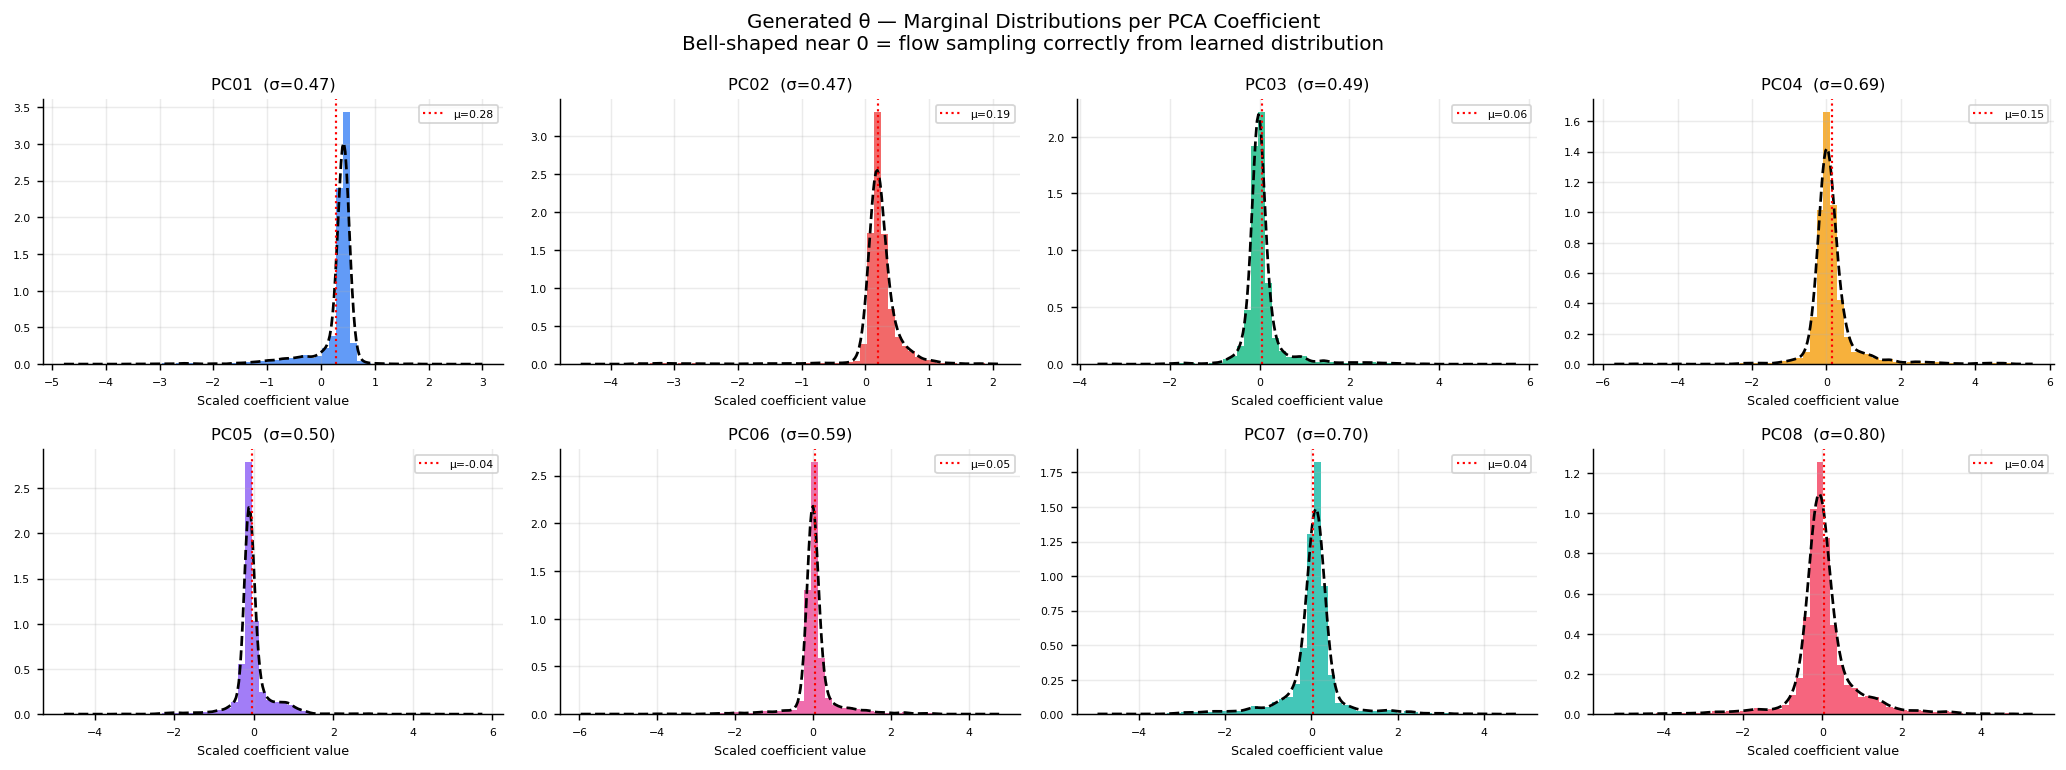

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(THETA_COLS):
    ax = axes[i]
    data = df[col].values
    ax.hist(data, bins=60, color=PALETTE[i], alpha=0.8, density=True, edgecolor='none')
    xs = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, gaussian_kde(data)(xs), color='black', lw=1.5, linestyle='--')
    ax.axvline(data.mean(), color='red', lw=1.2, linestyle=':', label=f'μ={data.mean():.2f}')
    ax.set_title(f'{PC_NAMES[i]}  (σ={data.std():.2f})', fontsize=9)
    ax.set_xlabel('Scaled coefficient value', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)

fig.suptitle('Generated θ — Marginal Distributions per PCA Coefficient\n'
             'Bell-shaped near 0 = flow sampling correctly from learned distribution', fontsize=11)
fig.tight_layout()
plt.show()

## 3 — Pairwise Correlation Heatmap (θ)

Shows how correlated the generated future-shape parameters are with each other.  
Strong off-diagonal values mean the flow learned that certain efficiency/trajectory shapes tend to co-occur.

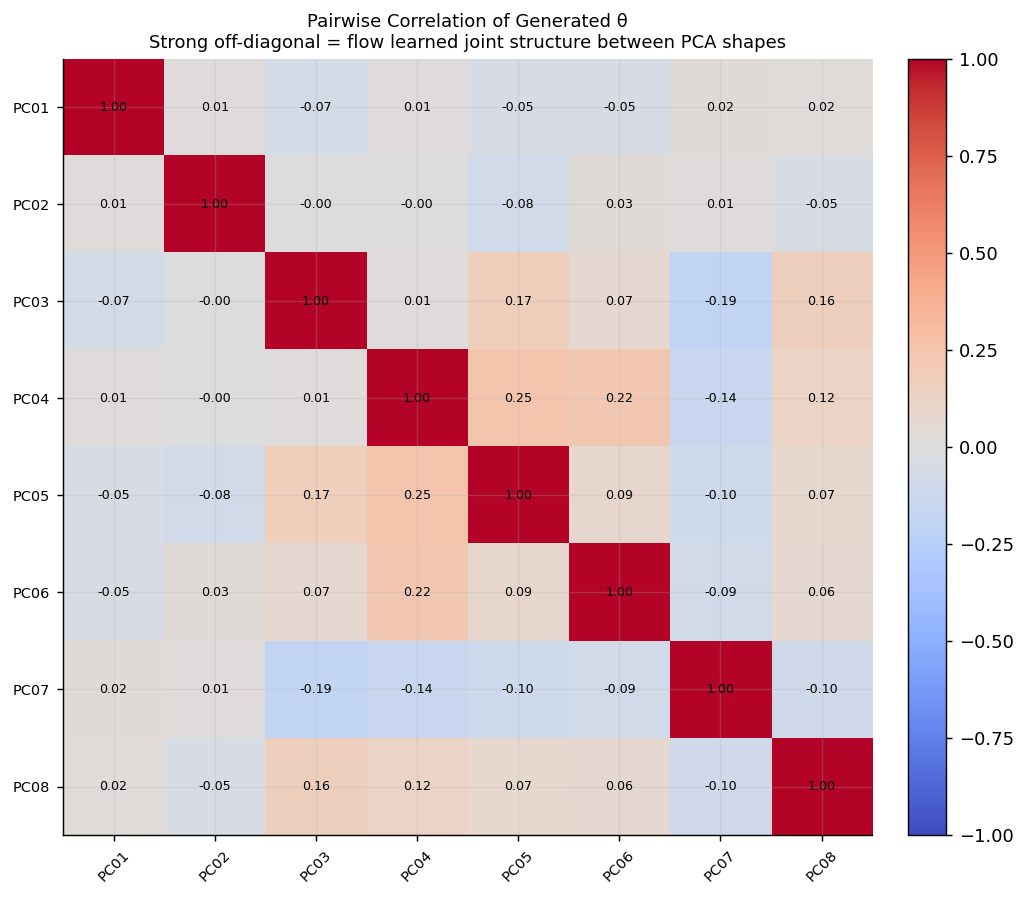

In [4]:
corr = df[THETA_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(8)); ax.set_xticklabels(PC_NAMES, rotation=45, fontsize=8)
ax.set_yticks(range(8)); ax.set_yticklabels(PC_NAMES, fontsize=8)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black')
ax.set_title('Pairwise Correlation of Generated θ\n'
             'Strong off-diagonal = flow learned joint structure between PCA shapes', fontsize=10)
fig.tight_layout()
plt.show()

## 4 — x̂ vs θ: Do Conditions Drive the Generated Futures?

Picks the 4 most variable x̂ sensors and scatters each against every θ coefficient.  
A visible trend means the conditional flow is correctly modulating futures based on current operating state.

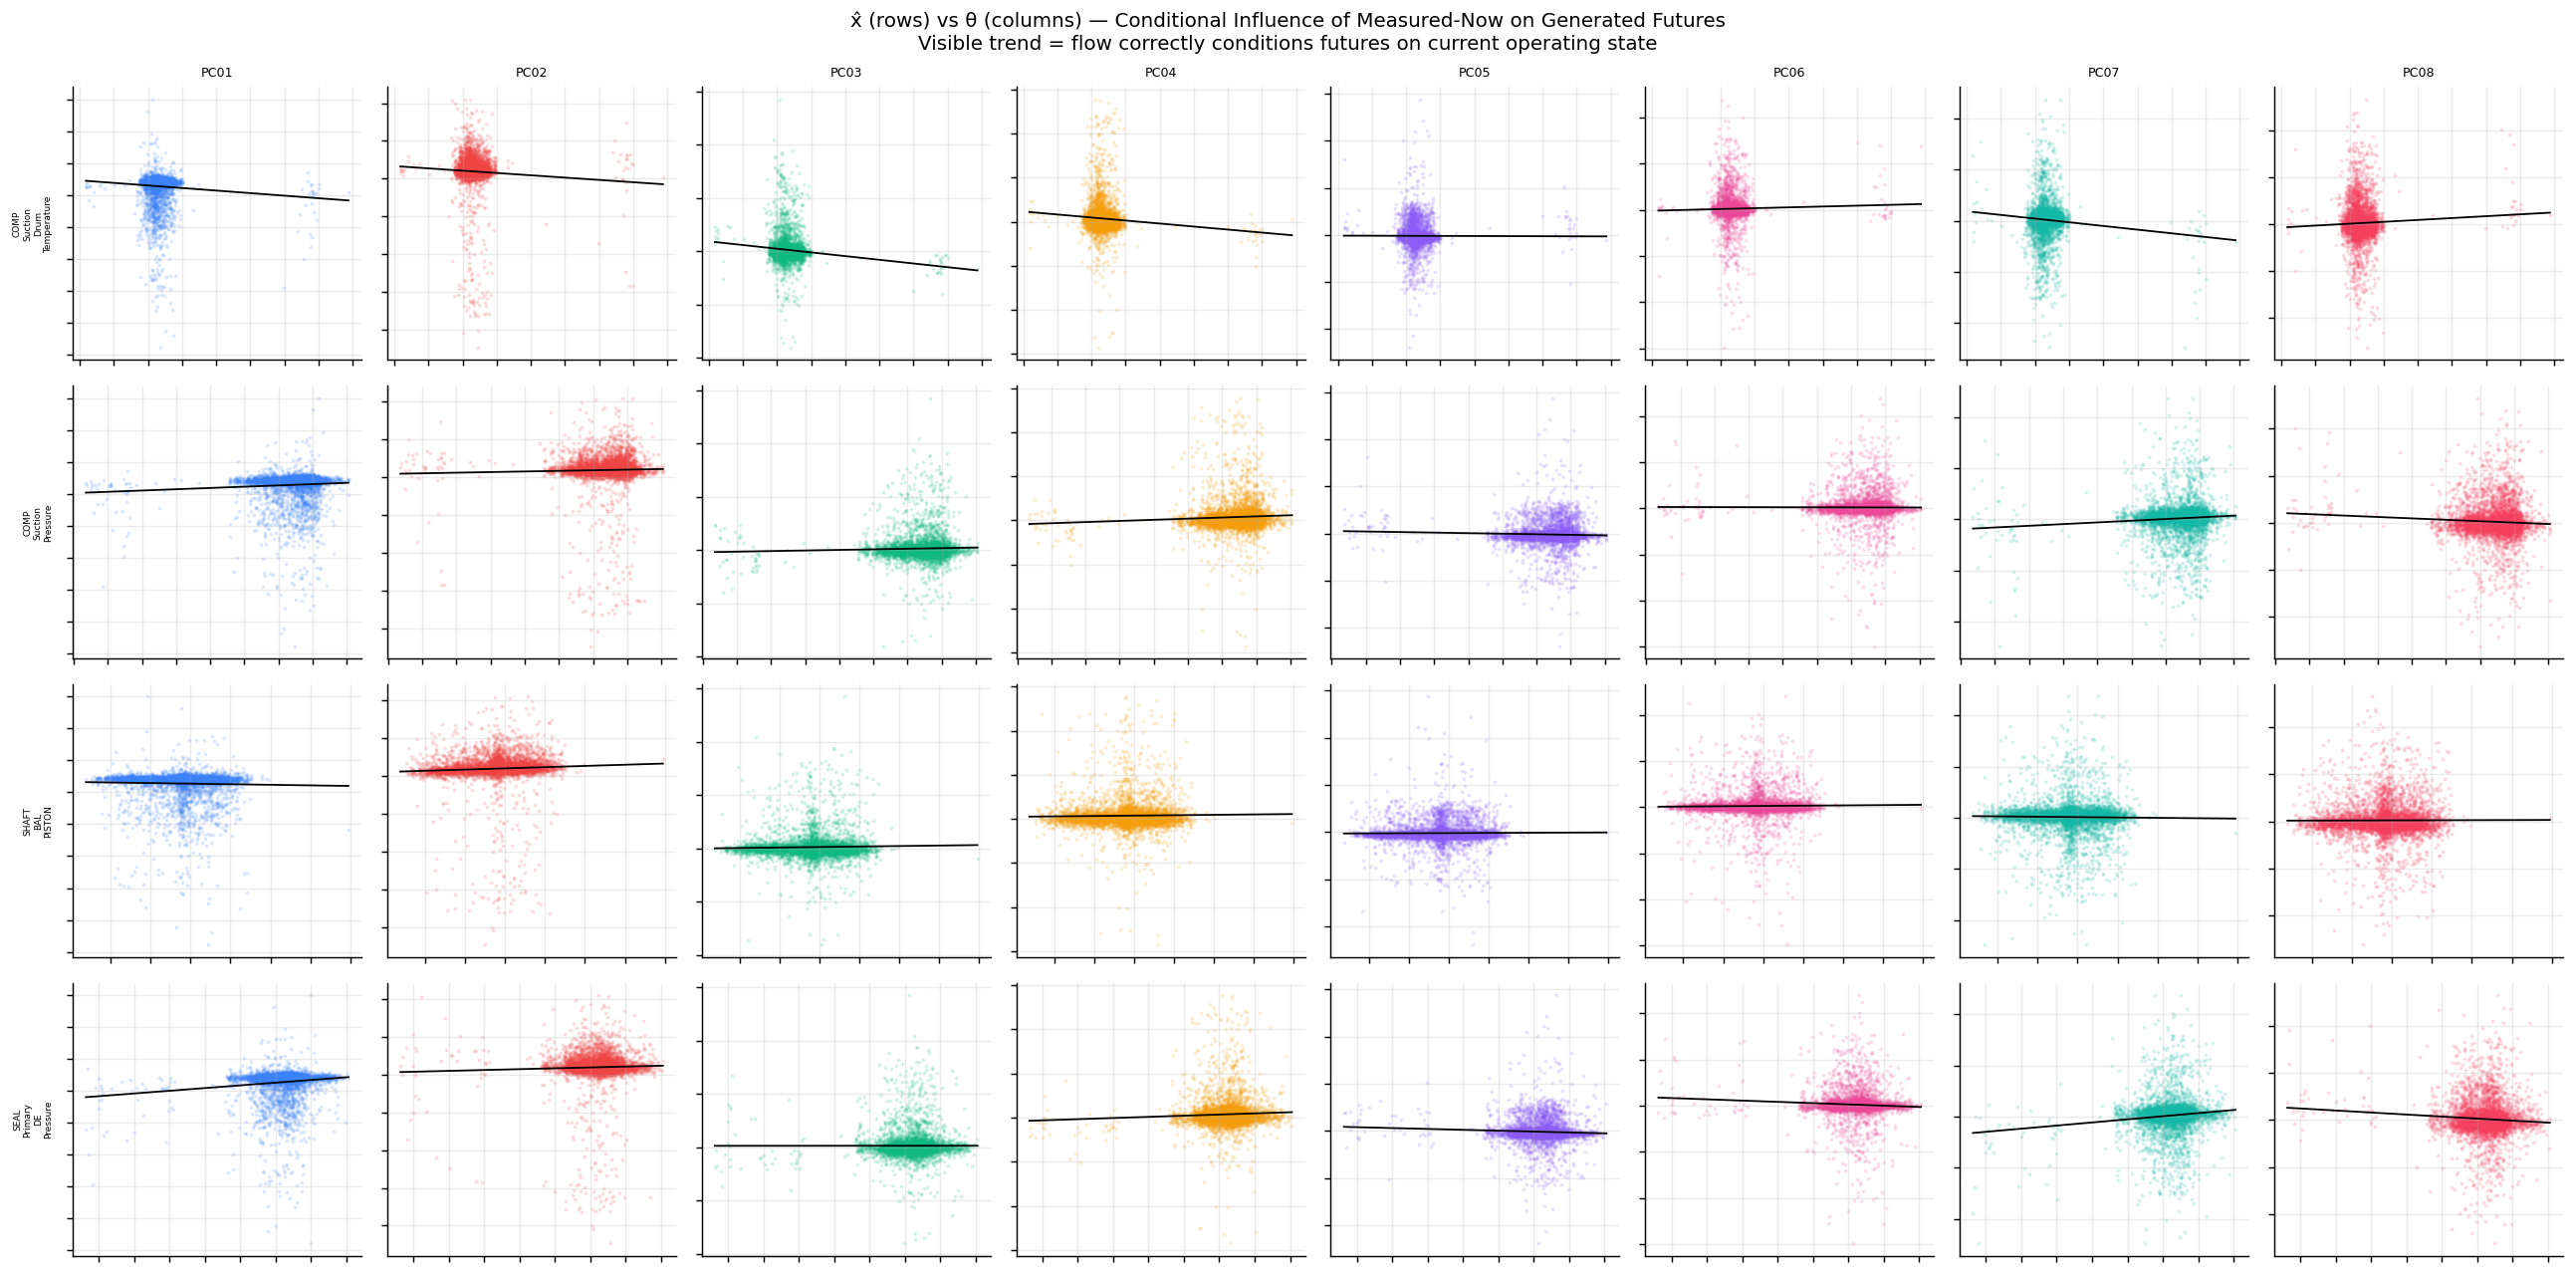

In [5]:
top_x = df[X_COLS].std().nlargest(4).index.tolist()

fig, axes = plt.subplots(4, 8, figsize=(20, 10))

for row, xcol in enumerate(top_x):
    for col, tcol in enumerate(THETA_COLS):
        ax = axes[row][col]
        ax.scatter(df[xcol], df[tcol], s=1.5, alpha=0.12,
                   color=PALETTE[col], rasterized=True)
        z = np.polyfit(df[xcol], df[tcol], 1)
        xr = np.linspace(df[xcol].min(), df[xcol].max(), 100)
        ax.plot(xr, np.polyval(z, xr), color='black', lw=1.0)
        if row == 0:
            ax.set_title(PC_NAMES[col], fontsize=7)
        if col == 0:
            ax.set_ylabel(xcol.replace('_', '\n'), fontsize=5)
        ax.set_xticklabels([]); ax.set_yticklabels([])
        ax.tick_params(labelsize=5)

fig.suptitle('x̂ (rows) vs θ (columns) — Conditional Influence of Measured-Now on Generated Futures\n'
             'Visible trend = flow correctly conditions futures on current operating state', fontsize=11)
fig.tight_layout()
plt.show()

## 5 — θ Space Coverage: 2D PCA Projection

Projects all 8 θ dimensions down to 2D to show the overall shape of the scenario cloud.  
A smooth, well-spread blob (no holes, no sharp edges) means the flow is covering the scenario space without mode collapse.

/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


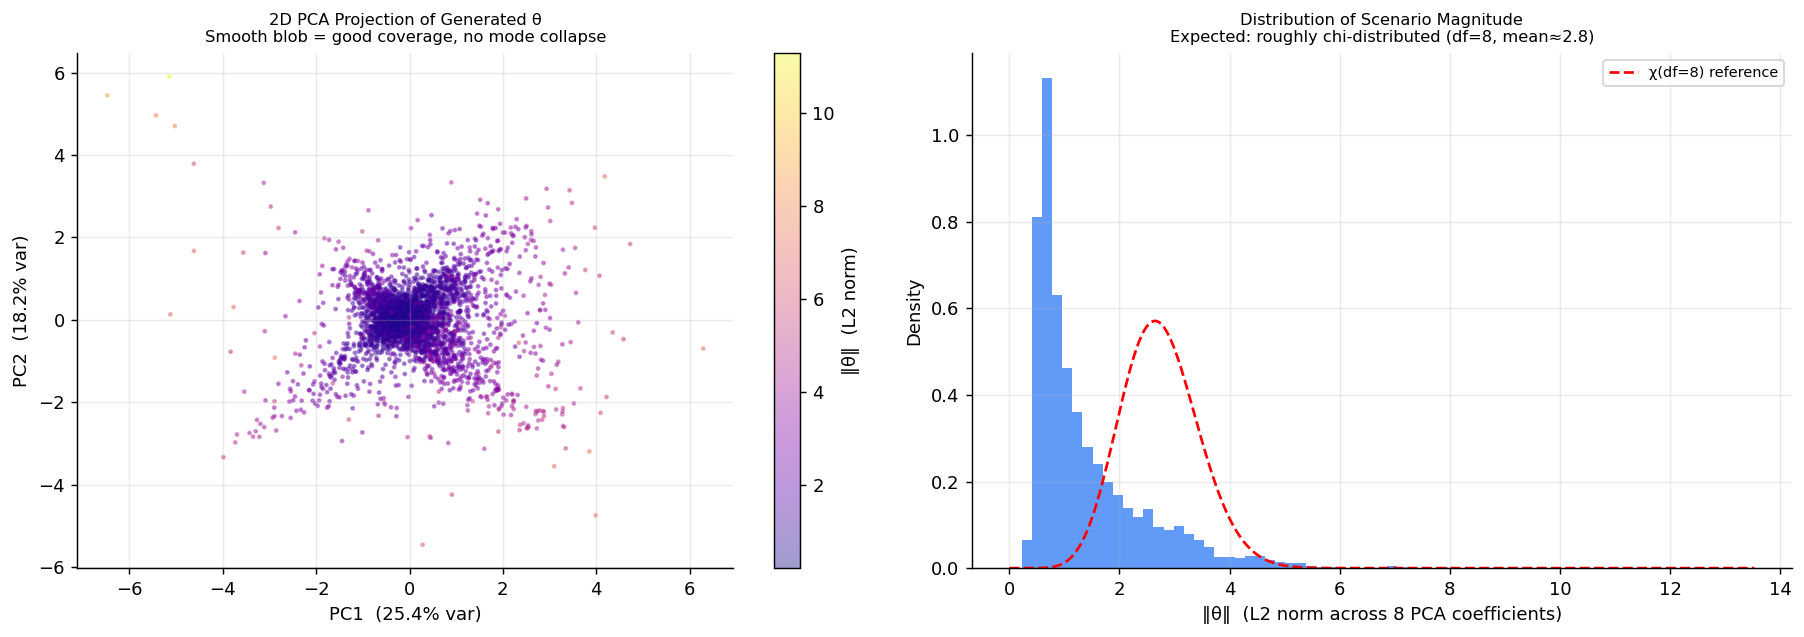

Explained variance by 2D projection: 43.7%
‖θ‖  mean=1.389  std=1.049  (ideal for N(0,I₈): mean≈2.83)


In [6]:
theta_np = df[THETA_COLS].values
pca2d = skPCA(n_components=2)
z2d   = pca2d.fit_transform(theta_np)
norms = np.linalg.norm(theta_np, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(z2d[:, 0], z2d[:, 1], c=norms, cmap='plasma',
                     s=3, alpha=0.4, rasterized=True)
plt.colorbar(sc, ax=axes[0], label='‖θ‖  (L2 norm)')
axes[0].set_title('2D PCA Projection of Generated θ\n'
                  'Smooth blob = good coverage, no mode collapse', fontsize=9)
axes[0].set_xlabel(f'PC1  ({pca2d.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2  ({pca2d.explained_variance_ratio_[1]*100:.1f}% var)')

axes[1].hist(norms, bins=60, color=PALETTE[0], alpha=0.8, density=True, edgecolor='none')
axes[1].set_xlabel('‖θ‖  (L2 norm across 8 PCA coefficients)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Scenario Magnitude\n'
                  'Expected: roughly chi-distributed (df=8, mean≈2.8)', fontsize=9)
xc = np.linspace(0, norms.max() * 1.2, 300)
axes[1].plot(xc, chi.pdf(xc, df=8), 'r--', lw=1.5, label='χ(df=8) reference')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Explained variance by 2D projection: {pca2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"‖θ‖  mean={norms.mean():.3f}  std={norms.std():.3f}  (ideal for N(0,I₈): mean≈2.83)")

## 6 — Rare Event Diagnosis: Is Importance Weighting Needed?

Measures how "unusual" each scenario is by computing its L2 distance from the batch mean — the same metric the proposed importance weighting scheme would use.

- **If the distribution is roughly Gaussian with no heavy tail** → the flow already learned the rare events adequately, weighting is optional.
- **If there is a long right tail with a small cluster of extreme outliers** → the flow is likely ignoring those scenarios, and importance weighting should be added to training.

── Importance weight distribution ──
  Percentile        Distance    Weight
  ────────────────────────────────────
     50th pctile        0.900     1.824
     75th pctile        1.720     2.576
     90th pctile        2.863     3.624
     95th pctile        3.522     4.228
     99th pctile        4.890     5.481
   99.9th pctile        7.267     7.660

  Fraction with weight > 3.0 (very rare): 17.80%
  Max weight: 11.36  (scenario at index 4587)


/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/asiwakoti/Desktop/Genesis/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


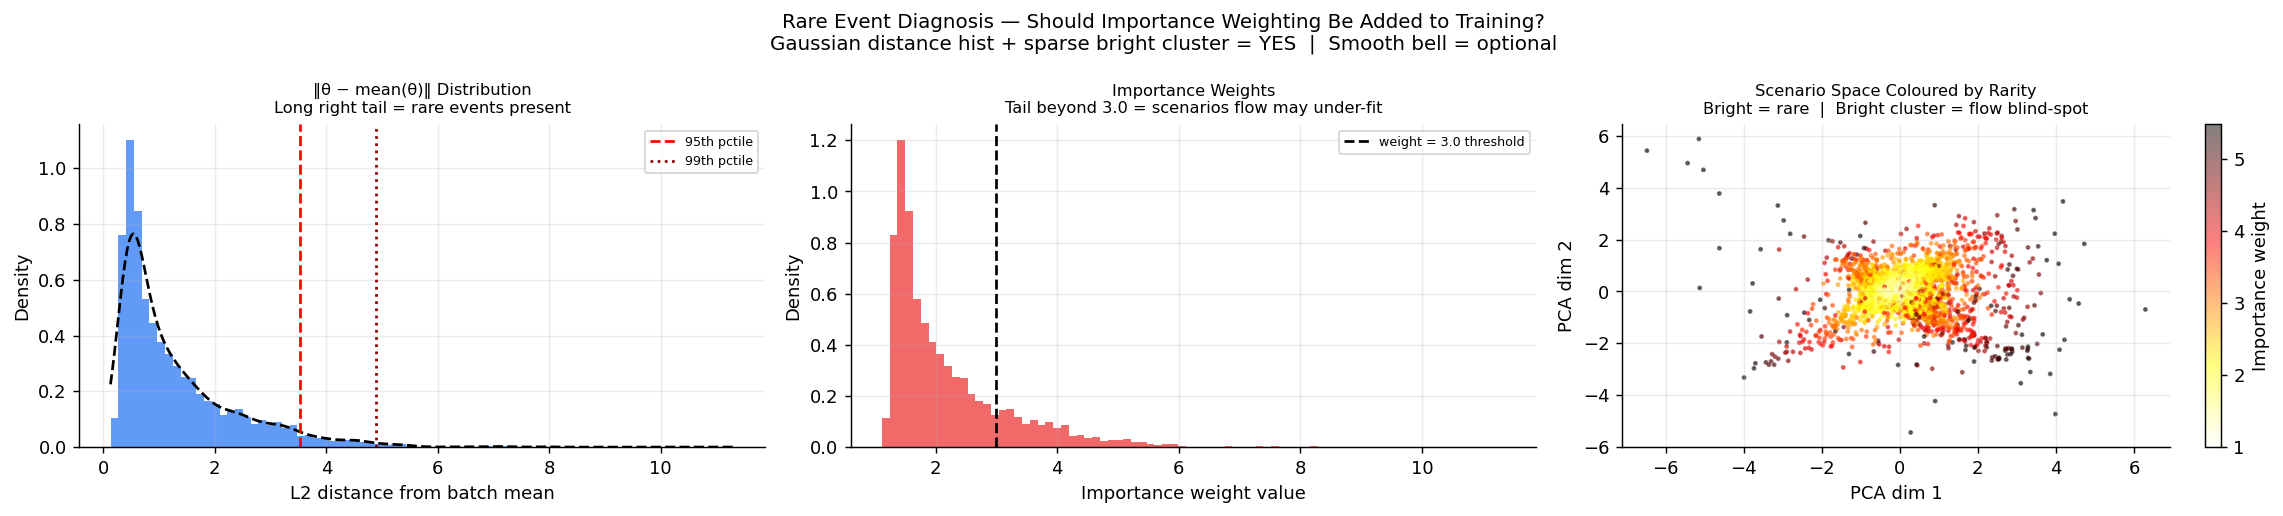


── VERDICT ──
  Distance skewness : 1.886  (> 1.0 = right-skewed = rare events present)
  ⚠️  Importance weighting RECOMMENDED — rare scenarios exist that the flow may under-fit.


In [7]:
theta_np = df[THETA_COLS].values  # (N, 8)

# ── Compute importance weight proxy (same formula the trainer would use) ──────
mean_theta = theta_np.mean(axis=0)
distances  = np.linalg.norm(theta_np - mean_theta, axis=1)   # (N,)
weights    = 1.0 + (distances / (distances.std() + 1e-5))     # same as trainer formula

# Percentile summary
pcts = [50, 75, 90, 95, 99, 99.9]
print("── Importance weight distribution ──")
print(f"  {'Percentile':<14}  {'Distance':>10}  {'Weight':>8}")
print(f"  {'─'*36}")
for p in pcts:
    d = np.percentile(distances, p)
    w = np.percentile(weights,   p)
    print(f"  {p:>5}th pctile   {d:>10.3f}  {w:>8.3f}")

frac_high = (weights > 3.0).mean() * 100
print(f"\n  Fraction with weight > 3.0 (very rare): {frac_high:.2f}%")
print(f"  Max weight: {weights.max():.2f}  (scenario at index {weights.argmax()})")

# ── Figure: distance histogram + weight histogram + scenario map ──────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Left: raw distance distribution
axes[0].hist(distances, bins=80, color=PALETTE[0], alpha=0.8, density=True, edgecolor='none')
xs = np.linspace(distances.min(), distances.max(), 300)
axes[0].plot(xs, gaussian_kde(distances)(xs), 'k--', lw=1.5)
axes[0].axvline(np.percentile(distances, 95), color='red', lw=1.5, linestyle='--', label='95th pctile')
axes[0].axvline(np.percentile(distances, 99), color='darkred', lw=1.5, linestyle=':', label='99th pctile')
axes[0].set_title('‖θ − mean(θ)‖ Distribution\nLong right tail = rare events present', fontsize=9)
axes[0].set_xlabel('L2 distance from batch mean')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=7)

# Middle: importance weight distribution
axes[1].hist(weights, bins=80, color=PALETTE[1], alpha=0.8, density=True, edgecolor='none')
axes[1].axvline(3.0, color='black', lw=1.5, linestyle='--', label='weight = 3.0 threshold')
axes[1].set_title('Importance Weights\nTail beyond 3.0 = scenarios flow may under-fit', fontsize=9)
axes[1].set_xlabel('Importance weight value')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=7)

# Right: 2D PCA projection coloured by weight
pca2d_diag = skPCA(n_components=2).fit_transform(theta_np)
sc = axes[2].scatter(pca2d_diag[:, 0], pca2d_diag[:, 1],
                     c=weights, cmap='hot_r', s=3, alpha=0.5,
                     vmin=1.0, vmax=np.percentile(weights, 99),
                     rasterized=True)
plt.colorbar(sc, ax=axes[2], label='Importance weight')
axes[2].set_title('Scenario Space Coloured by Rarity\nBright = rare  |  Bright cluster = flow blind-spot', fontsize=9)
axes[2].set_xlabel('PCA dim 1')
axes[2].set_ylabel('PCA dim 2')

fig.suptitle('Rare Event Diagnosis — Should Importance Weighting Be Added to Training?\n'
             'Gaussian distance hist + sparse bright cluster = YES  |  Smooth bell = optional', fontsize=11)
fig.tight_layout()
plt.show()

# ── Verdict ───────────────────────────────────────────────────────────────────
print("\n── VERDICT ──")
skew = float(pd.Series(distances).skew())
print(f"  Distance skewness : {skew:.3f}  (> 1.0 = right-skewed = rare events present)")
if skew > 1.0 or frac_high > 1.0:
    print("  ⚠️  Importance weighting RECOMMENDED — rare scenarios exist that the flow may under-fit.")
else:
    print("  ✅  Distribution is approximately symmetric — importance weighting is optional for this dataset.")